## 0. Import thư viện và cấu hình

In [1]:
import os
import pickle
import time
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import binomtest

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,   
)

from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
print('Đã tải xong tất cả thư viện cần thiết.')

# Thiết lập đường dẫn và đọc file pickle đã xử lý
_notebook_dir  = os.path.abspath('')
BASE_PATH      = os.path.abspath(os.path.join(_notebook_dir, '..', '..'))
PROC_DATA_PATH = os.path.join(BASE_PATH, 'data', 'processed')
FIG_PATH       = os.path.join(BASE_PATH, 'report', 'figures', 'lr')
os.makedirs(FIG_PATH, exist_ok=True)

PKL_PATH = os.path.join(PROC_DATA_PATH, 'processed_data.pkl')

with open(PKL_PATH, 'rb') as f:
    data = pickle.load(f)

FEATURE_NAMES = data['X_train'].columns.tolist()

X_train = data['X_train'].values.astype(np.float64)
y_train = data['y_train'].values.astype(int)
X_val   = data['X_val'].values.astype(np.float64)
y_val   = data['y_val'].values.astype(int)
X_test  = data['X_test'].values.astype(np.float64)
y_test  = data['y_test'].values.astype(int)
CLASS_WEIGHTS = data['class_weights']  # {0: w0, 1: w1}

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')
print(f'Số đặc trưng: {X_train.shape[1]}')
print(f'Class weights: {CLASS_WEIGHTS}')

Đã tải xong tất cả thư viện cần thiết.
Train : (90916, 24)
Val   : (12988, 24)
Test  : (25976, 24)
Số đặc trưng: 24
Class weights: {0: 0.8823540829596848, 1: 1.153844201335127}


## 1. Lý thuyết Linear Discriminant Analysis (LDA) và Quadratic Discriminant Analysis (QDA)

### 1.1 Mô hình sinh Gaussian trong phân lớp

Trong mô hình sinh (generative model), ta giả sử dữ liệu đặc trưng $ x $ của mỗi lớp $ C_k $ tuân theo phân phối Gaussian đa biến:

$$
p(x \mid C_k) = \mathcal{N}(x \mid \mu_k, \Sigma_k)
$$

Trong đó:
- $ \mu_k $: vector kì vọng của lớp $ k $  
- $ \Sigma_k $: ma trận hiệp phương sai của lớp $ k $

Ngoài ra, mỗi lớp có xác xuất tiên nghiệm: 
$$
\pi_k = P(C_k)
$$

Để xây dựng mô hình, các tham số này được ước lượng dựa trên dữ liệu huấn luyện thông qua phương pháp cực đại hóa khả năng (Maximum Likelihood Estimation - MLE):

Vector trung bình ước lượng: $ \hat{\mu}_k = \frac{1}{N_k} \sum_{n \in C_k} x_n $

Ma trận hiệp phương sai ước lượng: $ \hat{\Sigma}_k = \frac{1}{N_k} \sum_{n \in C_k} (x_n - \hat{\mu}_k)(x_n - \hat{\mu}_k)^T $


## 1.2 Mô hình Linear Discriminant Analysis (LDA)

LDA giả định rằng tất cả các lớp chia sẻ cùng một ma trận hiệp phương sai, tức là $\Sigma_0 = \Sigma_1 =....= \Sigma$ 

Khi đó, ma trận hiệp phương sai chung được ước lượng như sau:

$$
\hat{\Sigma} = \sum_{k} \frac{N_k}{N} \hat{\Sigma}_k
$$

Áp dụng định lý Bayes: 
$$
p(C_k \mid x) \propto p(x \mid C_k)\, p(C_k)
$$

Lấy log và rút gọn, ta được phân biệt của LDA được định nghĩa như sau:

$$
\delta_k(x) = x^T \Sigma^{-1} \mu_k 
- \frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k 
+ \log \pi_k
$$

trong đó $ \pi_k = P(C_k) $ là xác suất tiên nghiệm của lớp.

### Nhận xét:
Vì LDA sử dụng một ma trận hiệp phương sai cho mọi lớp, các hạng tử bậc hai trong log-likelihood bị triệt tiêu, dẫn đến **biên quyết định giữa các lớp có dạng tuyến tính**. Điều này giúp mô hình ổn định nhưng sẽ bị giới hạn khi dữ liệu có cấu trúc phức tạp.


## 1.3 Mô hình Quadratic Discriminant Analysis (QDA)

QDA là sự mở rộng của LDA bằng cách cho phép mỗi lớp $C_k$ có hiệp phương sai riêng $\Sigma_k$.

$$
p(x \mid C_k) = \mathcal{N}(x \mid \mu_k, \Sigma_k)
$$

Khi đó, hàm phân biệt QDA giữ lại thành phần bậc 2:

$$
\delta_k(x) = 
-\frac{1}{2} \log |\Sigma_k|
- \frac{1}{2} (x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k)
+ \log \pi_k
$$

### Nhận xét:
Với các thành phần bậc 2 giúp QDA tạo ra các **biên quyết định phi tuyến**(đường cong bậc 2), có khả năng biểu diễn tốt các tập dữ liệu mà các lớp có độ phân tán khác biệt rõ rệt. Mặc dù vậy, QDA lại đòi hỏi ước lượng nhiều tham số hơn do đó dễ dẫn đến hiện tượng **quá khớp** nếu tập dữ liệu huấn luyện có kích thước nhỏ. 


## 1.4 Đánh giá đặc trưng qua tỉ số Fisher

Để đánh giá khả năng phân biệt lớp của từng đặc trưng $ x_j $ đơn lẻ , ta sử dụng tỷ số Fisher:

$$
J_j = \frac{(\mu_{1j} - \mu_{0j})^2}{s_{1j}^2 + s_{0j}^2}
$$

Trong đó:
- $ \mu_{1j}, \mu_{0j} $: trung bình của đặc trưng $ j $ ở hai lớp  
- $ s_{1j}^2, s_{0j}^2 $: phương sai của đặc trưng $ j $

### Ý nghĩa:
- Tỉ số so sánh trực tiếp khoảng cách giữa hai lớp (phương sai giữa các lớp - tử số) với độ phân tán của dữ liệu bên trong nội bộ lớp (phương sai trong lớp - mẫu số). 
- Tỉ số $J_j$ càng lớn thì đặc trưng phân biệt lớp càng cao.


## 1.5 Fisher’s Linear Discriminant

Mở rộng từ tỉ số Fisher trên trong không gian đa chiều, LDA tìm kiếm một vector chiếu $w$ sao cho tỉ số giữa độ phân tán giữa các lớp ($S_B$) và độ phân tán trong lớp ($S_W$) đạt cực đại: 

$$
J(w) = \frac{w^T S_B w}{w^T S_W w}
$$

Trong đó:
- $ S_B $: ma trận phân tán giữa lớp
- $ S_W $: ma trận phân tán trong lớp

Việc tối ưu hàm mục tiêu này đồng nghĩa với việc tìm ra một không gian chiếu mà tại đó các lớp được tách rời nhau xa nhất có thể trong khi các điểm dữ liệu cùng lớp lại co cụm chặt chẽ với nhau. Nghiệm tối ưu của bài toán được xác định bởi:

$$
w = \alpha S_W^{-1}(m_1 - m_0), \quad với \; \alpha \neq 0
$$


## 1.6 Giới hạn số chiều phân biệt

Tính chất quan trọng của Fisher-LDA là giới hạn về số chiều không gian phân biệt. Đối với bài toán nhị phân ($C = 2$), số lượng không gian chiều tối đa có thể trích xuất là: 

$$
d_{\text{max}} = C - 1 = 1
$$

Do đó, bất chấp dữ liệu ban đầu có bao nhiêu chiều, không gian phân biệt cốt lõi do LDA tạo ra chỉ là một chiều duy nhất.


## 2. Cài đặt mô hình LDA, QDA và đưa ra nhận xét

### 2.1 Tính toán các tham số thống kê (trung bình và hiệp phương sai)

Tiến hành tính toán các tham số thống kê cần thiết cho mô hình LDA và QDA: Xác suất tiên nghiệm, vector trung bình và ma trận hiệp phương sai.


In [2]:
def estimate_generative_parameters(X, y, epsilon=1e-6):
    X = np.asarray(X, float)
    y = np.asarray(y)

    classes = np.unique(y)
    n_samples, n_features = X.shape
    n_classes = len(classes)

    params = {}
    Sigma_shared = np.zeros((n_features, n_features))

    for k in classes:
        X_k = X[y == k]
        N_k = len(X_k)

        mu_k = X_k.mean(axis=0)
        diff = X_k - mu_k

        # covariance riêng từng lớp cho QDA
        Sigma_k = np.cov(X_k, rowvar=False) + epsilon * np.eye(n_features)

        # prior
        pi_k = N_k / n_samples

        # pooled covariance cho LDA
        Sigma_shared += diff.T @ diff

        params[k] = {
            "mu": mu_k,
            "Sigma": Sigma_k,
            "pi": pi_k
        }

    Sigma_shared = Sigma_shared / (n_samples - n_classes)
    Sigma_shared += epsilon * np.eye(n_features)

    return params, Sigma_shared

# Fit parameters
params, Sigma_lda = estimate_generative_parameters(X_train, y_train)

print("=== Tham số ước lượng cho QDA ===")

for k, p in params.items():
    print(f"\nLớp C_{k}:")
    print(f"  Xác suất tiên nghiệm  (π_{k}): {p['pi']:.4f}")
    print(f"  Vector trung bình (μ_{k}): {p['mu'][:5]} ...")   # in 5 giá trị đầu
    print(f"  Kích thước hiệp phương sai: {p['Sigma'].shape}")

print("\n=== Tham số cho LDA ===")
print(f"  Hiệp phương sai chung: {Sigma_lda.shape}")

=== Tham số ước lượng cho QDA ===

Lớp C_0:
  Xác suất tiên nghiệm  (π_0): 0.5667
  Vector trung bình (μ_0): [ 0.48783944  0.24695743 -0.12038716  0.49073157 -0.26077709] ...
  Kích thước hiệp phương sai: (24, 24)

Lớp C_1:
  Xác suất tiên nghiệm  (π_1): 0.4333
  Vector trung bình (μ_1): [0.49914968 0.10010915 0.15742889 0.0729751  0.34101518] ...
  Kích thước hiệp phương sai: (24, 24)

=== Tham số cho LDA ===
  Hiệp phương sai chung: (24, 24)


### 2.2 Cài đặt LDA với hiệp phương sai chung

In [3]:
class MyLDA:
    def __init__(self, reg=1e-6):
        self.reg = reg

    def fit(self, X, y):
        X = np.asarray(X, float)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        params, Sigma_shared = estimate_generative_parameters(X, y, epsilon=self.reg)

        self.mu_ = {c: params[c]["mu"] for c in self.classes_}
        self.prior_ = {c: params[c]["pi"] for c in self.classes_}
        self.Sigma_ = Sigma_shared
        self.Sigma_inv_ = np.linalg.pinv(self.Sigma_)
        return self

    def _delta(self, X, c):
        X = np.asarray(X, float)
        mu = self.mu_[c]
        pi = self.prior_[c]
        return X @ self.Sigma_inv_ @ mu - 0.5 * mu.T @ self.Sigma_inv_ @ mu + np.log(pi)

    def decision_function(self, X):
        X = np.asarray(X, float)
        scores = np.column_stack([self._delta(X, c) for c in self.classes_])

        if len(self.classes_) == 2:
            return scores[:, 1] - scores[:, 0]
        return scores

    def predict_proba(self, X):
        X = np.asarray(X, float)

        if len(self.classes_) == 2:
            scores = self.decision_function(X)
            p1 = 1 / (1 + np.exp(-scores))
            return np.c_[1 - p1, p1]

        scores = np.column_stack([self._delta(X, c) for c in self.classes_])
        scores = scores - scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(scores)
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)

    def predict(self, X):
        X = np.asarray(X, float)

        if len(self.classes_) == 2:
            proba = self.predict_proba(X)[:, 1]
            return np.where(proba >= 0.5, self.classes_[1], self.classes_[0])

        scores = self.decision_function(X)
        idx = np.argmax(scores, axis=1)
        return self.classes_[idx]
    
print("Đã cài đặt LDA")

Đã cài đặt LDA


### 2.4 Cài đặt QDA với hiệp phương sai riêng

In [4]:
class MyQDA:
    def __init__(self, reg=1e-4):
        self.reg = reg

    def fit(self, X, y):
        X = np.asarray(X, float)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        params, _ = estimate_generative_parameters(X, y, epsilon=self.reg)

        self.mu_ = {}
        self.Sigma_ = {}
        self.Sigma_inv_ = {}
        self.logdet_ = {}
        self.prior_ = {}

        for c in self.classes_:
            self.mu_[c] = params[c]["mu"]
            self.Sigma_[c] = params[c]["Sigma"]
            self.Sigma_inv_[c] = np.linalg.pinv(params[c]["Sigma"])
            self.logdet_[c] = np.linalg.slogdet(params[c]["Sigma"])[1]
            self.prior_[c] = params[c]["pi"]

        return self

    def _delta(self, X, c):
        X = np.asarray(X, float)
        mu = self.mu_[c]
        Sigma_inv = self.Sigma_inv_[c]
        logdet = self.logdet_[c]
        pi = self.prior_[c]

        diff = X - mu
        quad = np.sum((diff @ Sigma_inv) * diff, axis=1)

        return -0.5 * logdet - 0.5 * quad + np.log(pi)

    def decision_function(self, X):
        X = np.asarray(X, float)
        scores = np.column_stack([self._delta(X, c) for c in self.classes_])
        return scores

    def predict_proba(self, X):
        scores = self.decision_function(X)
        scores = scores - scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(scores)
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)

    def predict(self, X):
        scores = self.decision_function(X)
        idx = np.argmax(scores, axis=1)
        return self.classes_[idx]

print("Đã cài đặt QDA")

Đã cài đặt QDA


### 2.4 Fisher ratio cho từng đặc trưng và xếp hạng discriminability

Như đã trình bày trong phần Fisher’s Linear Discriminant, mục tiêu của LDA là tìm một hướng chiếu $w$ sao cho hàm mục tiêu $J(w)$ đạt cực đại. Thay vì xét đồng thời toàn bộ không gian đặc trưng, ta có thể đơn giản hóa bài toán bằng cách đánh giá khả năng phân biệt lớp của từng đặc trưng riêng lẻ $x_j$ với Fisher score:

$$
J_j = \frac{(\mu_{1j} - \mu_{0j})^2}{s_{1j}^2 + s_{0j}^2}
$$

Biểu thức này phản ánh trực tiếp nguyên lý của LDA:
- tử số $(\mu_{1j} - \mu_{0j})^2 $ thể hiện mức độ khác biệt giữa hai lớp
- mẫu số $s_{1j}^2 + s_{0j}^2$ thể hiện mức độ phân tán của dữ liệu trong từng lớp.

Do đó, một đặc trưng sẽ có Fisher score cao khi:
- trung bình của hai lớp khác nhau rõ rệt,
- và dữ liệu trong từng lớp ít phân tán.

Ngược lại, nếu trung bình giữa hai lớp gần nhau hoặc phương sai trong lớp lớn, thì đặc trưng đó có khả năng phân biệt kém.

Dựa trên nguyên lý này, ta tính Fisher score cho từng đặc trưng trong tập huấn luyện, sau đó sắp xếp giảm dần để xác định những biến có mức độ phân biệt lớp mạnh nhất. Đây là cơ sở để xếp hạng đặc trưng và hỗ trợ lựa chọn biến trước khi xây dựng mô hình LDA hoặc QDA.

In [5]:
def fisher_scores(X, y, feature_names=None, eps=1e-12):
    X = np.asarray(X, float)
    y = np.asarray(y)

    classes = np.unique(y)
    assert len(classes) == 2, "Fisher score chỉ áp dụng cho bài toán nhị phân"

    c0, c1 = classes
    X0, X1 = X[y == c0], X[y == c1]

    # mean
    mu0 = X0.mean(axis=0)
    mu1 = X1.mean(axis=0)

    # variance (unbiased)
    var0 = X0.var(axis=0, ddof=1)
    var1 = X1.var(axis=0, ddof=1)

    if feature_names is None:
        feature_names = [f"feature_{i}" for i in range(X.shape[1])]

    # Fisher score
    scores = (mu1 - mu0) ** 2 / (var0 + var1 + eps)

    df = pd.DataFrame({
        'feature': feature_names,
        'fisher_score': scores
    })

    return df.sort_values('fisher_score', ascending=False).reset_index(drop=True)

fisher_df = fisher_scores(X_train, y_train, FEATURE_NAMES)
fisher_df.head(15)

,feature,fisher_score
0,Online boarding,0.692436
1,Class_Business,0.691871
2,Type of Travel,0.549549
3,Class_Eco,0.529077
4,Inflight entertainment,0.390799
5,Seat comfort,0.285542
6,On-board service,0.241252
7,Leg room service,0.226694
8,Cleanliness,0.212541
9,Flight Distance,0.189841


Trong bài toán này, bên cạnh việc xây dựng mô hình phân lớp nhóm cũng chú trọng xác định các đặc trưng có khả năng phân biệt hai lớp một cách hiệu quả, điển hình như **Wifi** và **Delay**.

Vì vậy, nhóm tiến hành so sánh trực tiếp các đặc trưng này thông qua Fisher score, thay vì đưa ra các nhận xét mang tính tổng quát. Cách tiếp cận này giúp làm rõ mức độ đóng góp của từng biến và nâng cao tính thuyết phục của phần phân tích.

In [6]:
selected_features = [
    "Inflight wifi service",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]
print("So sánh Fisher score của các đặc trưng Wifi và Delay:")
display(
    fisher_df[
        fisher_df["feature"].isin(selected_features)
    ]
    .sort_values("fisher_score", ascending=False)
    .reset_index(drop=True)
)

So sánh Fisher score của các đặc trưng Wifi và Delay:


,feature,fisher_score
0,Inflight wifi service,0.170445
1,Arrival Delay in Minutes,0.020967
2,Departure Delay in Minutes,0.010256


- **Inflight wifi service** có Fisher score khoảng **0.17**, cao hơn đáng kể so với các biến liên quan đến độ trễ.
- Trong khi đó, **Arrival Delay in Minutes** và **Departure Delay in Minutes** có Fisher score rất thấp (lần lượt khoảng **0.021** và **0.010**).

Điều này cho thấy:
- Chất lượng **Wifi trên máy bay** có sự khác biệt rõ rệt giữa hai nhóm hành khách và đóng vai trò nhất định trong việc phân biệt mức độ hài lòng.
- Ngược lại, các yếu tố liên quan đến **độ trễ chuyến bay (Delay)** gần như không có khả năng phân biệt tốt giữa hai lớp, do giá trị Fisher score rất nhỏ.

Từ kết quả trên, có thể kết luận rằng:
- Các yếu tố liên quan đến **trải nghiệm dịch vụ** (như boarding, hạng vé, giải trí, wifi) có ảnh hưởng mạnh hơn đến sự khác biệt giữa hai lớp.
- Các yếu tố **Delay** tuy quan trọng về mặt vận hành, nhưng trong dữ liệu này lại không phải là biến quyết định trong việc phân loại mức độ hài lòng của hành khách.

### 2.5 Decision boundary của LDA và QDA trong không gian 2D

Đường biên quyết định của mô hình huấn luyện trên toàn bộ đặc trưng tồn tại trong không gian nhiều chiều, nên không thể biểu diễn trực tiếp trên mặt phẳng 2D. Vì vậy, các hình decision boundary 2D trong báo cáo chỉ mang tính minh họa trực quan khi mô hình được huấn luyện trên 2 đặc trưng tiêu biểu hoặc sau khi giảm chiều về 2D.

Vì thế nên nhóm lựa chọn đặc trưng có Fisher score cao nhất để tiến hành vẽ đường quyết định

In [7]:
# Lấy top 2 feature có Fisher score cao nhất
top2_features = fisher_df['feature'].iloc[:2].tolist()

top2_idx = [FEATURE_NAMES.index(f) for f in top2_features]

# Lấy dữ liệu cho 2 feature này
X_train_2d = X_train[:, top2_idx].astype(float)
X_test_2d  = X_test[:, top2_idx].astype(float)

# LDA và QDA trên 2 đặc trưng
lda_2d = MyLDA(reg=1e-6).fit(X_train_2d, y_train)
qda_2d = MyQDA(reg=1e-4).fit(X_train_2d, y_train)

# Dự đoán trên test
y_pred_lda_2d = lda_2d.predict(X_test_2d)
y_pred_qda_2d = qda_2d.predict(X_test_2d)

print("Top 2 features dùng để vẽ boundary:", top2_features)
print("LDA 2D accuracy:", accuracy_score(y_test, y_pred_lda_2d))
print("QDA 2D accuracy:", accuracy_score(y_test, y_pred_qda_2d))

Top 2 features dùng để vẽ boundary: ['Online boarding', 'Class_Business']
LDA 2D accuracy: 0.775408068986757
QDA 2D accuracy: 0.775408068986757


Đường quyết định của LDA và QDA xuống 2D với 2 đặc trưng 'Online boarding' và 'Class_Business'.

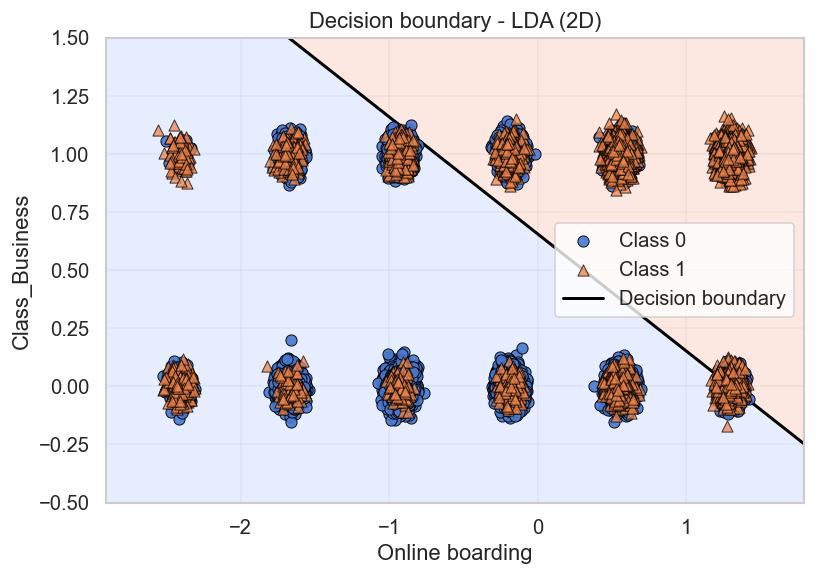

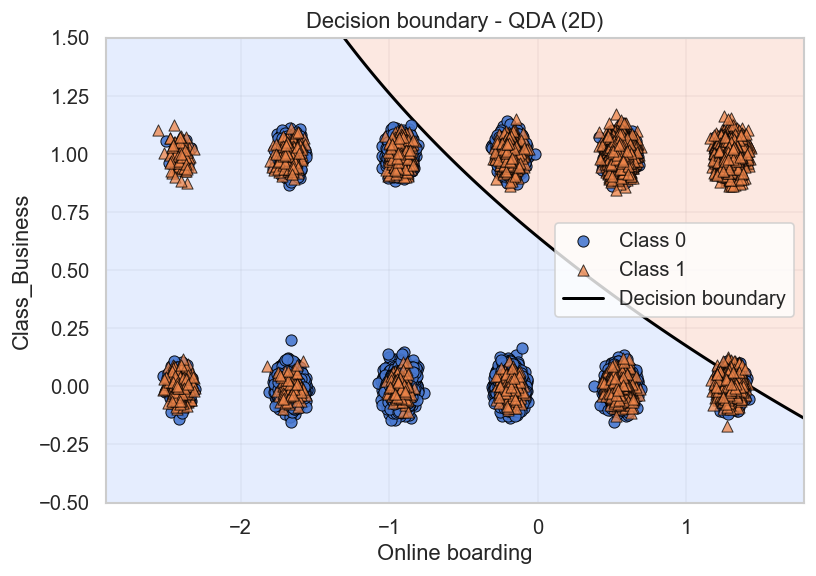

In [8]:
def plot_decision_boundary(model, X, y, title, feature_names, threshold=0.5, jitter=0.04):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)

    classes = np.unique(y)

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    proba = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    zz = (proba >= threshold).astype(int)

    plt.figure(figsize=(7, 5))

    # tô nền vùng dự đoán
    plt.contourf(
        xx, yy, zz,
        levels=[-0.5, 0.5, 1.5],
        alpha=0.22,
        cmap="coolwarm"
    )

    # vẽ đường biên
    plt.contour(
        xx, yy, proba,
        levels=[threshold],
        colors="black",
        linewidths=1.8
    )

    # jitter để tránh các điểm bị chồng lên nhau
    rng = np.random.default_rng(42)
    X_plot = X.copy()
    X_plot[:, 0] += rng.normal(0, jitter, size=X.shape[0])
    X_plot[:, 1] += rng.normal(0, jitter, size=X.shape[0])

    scatter_handles = []

    # vẽ class 0
    sc0 = plt.scatter(
        X_plot[y == 0, 0],
        X_plot[y == 0, 1],
        label="Class 0",
        s=45,
        alpha=0.9,
        marker="o",
        edgecolors="black",
        linewidths=0.6,
        zorder=3
    )
    scatter_handles.append(sc0)

    # vẽ class 1
    sc1 = plt.scatter(
        X_plot[y == 1, 0],
        X_plot[y == 1, 1],
        label="Class 1",
        s=45,
        alpha=0.75,
        marker="^",
        edgecolors="black",
        linewidths=0.6,
        zorder=4
    )
    scatter_handles.append(sc1)

    boundary_handle = Line2D(
        [0], [0],
        color="black",
        lw=1.8,
        label="Decision boundary"
    )

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title)
    plt.legend(handles=scatter_handles + [boundary_handle])
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_decision_boundary(
    lda_2d, X_test_2d, y_test,
    "Decision boundary - LDA (2D)", top2_features
)

plot_decision_boundary(
    qda_2d, X_test_2d, y_test,
    "Decision boundary - QDA (2D)", top2_features
)

**Nhận xét**:
- Mặc dù LDA tạo ra một đường biên tuyến tính rõ ràng, nhưng với hai đặc trưng được chọn mô hình chưa phân tách tốt hai lớp. Các điểm dữ liệu chồng lấn tại hầu hết các vùng, nhiều điểm thuộc class 1 nhưng nằm trong vùng dự đoán của class 0 và ngược lại.
- Mô hình QDA cho phép mỗi lớp có ma trận hiệp phương sai riêng, nên đường biên quyết định trở thành đường cong phi tuyến. Nhưng đường biên của QDA cũng không phân loại được chính xác, vẫn bị chồng lấn tương tự với LDA.
- Điều này cho thấy QDA chỉ cải thiện độ linh hoạt Decision Boundary, nhưng không cải thiện hiệu quả phân loại. 
- Từ kết quả trên cho thấy 2 đặc trưng được lựa chọn có ảnh hưởng nhất định đến việc phân biệt lớp, tuy nhiên không đủ mạnh để tách biệt hoàn toàn giữa 2 lớp dữ liệu. Vì thế cần bổ sung thêm các đặc trưng để cải thiện kết quả.

## 3. Đánh giá mô hình

### 3.1 Huấn luyện mô hình trên toàn bộ đặc trưng và đánh giá trên tập test

Đánh giá tổng quan khả năng phân lớp của 2 mô hình với các chỉ số cốt lõi bao gồm: Accuracy, Precision, Recall, F1-score, ROC-AUC, Average Precision (AP), và Log-loss.

- Dù dữ liệu Airline Passenger Satisfaction khá cân bằng, việc kết hợp F1-score và ROC-AUC giúp chúng ta đánh giá chính xác hơn khả năng nhận diện lớp hành khách "Hài lòng" (Satisfied - Class 1) của mô hình.

In [9]:
# Hàm đánh giá classifier với các metric quan trọng
def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name='Model'):
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - start

    y_pred = model.predict(X_test)
    y_proba_all = model.predict_proba(X_test)

    # xác định lớp dương cho bài toán nhị phân
    classes = np.asarray(model.classes_)
    if len(classes) != 2:
        raise ValueError("Hàm này hiện tại chỉ dùng cho bài toán nhị phân.")

    positive_class = classes[1]
    positive_idx = 1  # vì predict_proba của bạn trả theo đúng thứ tự model.classes_
    y_prob = y_proba_all[:, positive_idx]

    metrics = {
        'model': model_name,
        'positive_class': positive_class,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label=positive_class, zero_division=0),
        'recall': recall_score(y_test, y_pred, pos_label=positive_class, zero_division=0),
        'f1': f1_score(y_test, y_pred, pos_label=positive_class, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'avg_precision': average_precision_score(y_test == positive_class, y_prob),
        'log_loss': log_loss(y_test, y_proba_all, labels=classes),
        'fit_time_sec': fit_time
    }

    return metrics, y_pred, y_prob, y_proba_all

lda_full = MyLDA(reg=1e-6)
qda_full = MyQDA(reg=1e-4)

lda_metrics, y_pred_lda, y_prob_lda, y_proba_lda_all = evaluate_classifier(
    lda_full, X_train, y_train, X_test, y_test, model_name='MyLDA'
)

qda_metrics, y_pred_qda, y_prob_qda, y_proba_qda_all = evaluate_classifier(
    qda_full, X_train, y_train, X_test, y_test, model_name='MyQDA'
)

test_results_df = pd.DataFrame([lda_metrics, qda_metrics])
display(test_results_df.round(4))

,model,positive_class,accuracy,precision,recall,f1,roc_auc,avg_precision,log_loss,fit_time_sec
0,MyLDA,1,0.8690,0.8646,0.8319,0.8479,0.9252,0.9270,0.3497,0.0706
1,MyQDA,1,0.8534,0.8523,0.8057,0.8283,0.9171,0.9228,0.6506,0.0691


**Nhận xét**:
- Hiệu năng của LDA vượt trội hơn QDA trên mọi mặt.
- Giải thích: Việc LDA hoạt động tốt hơn QDA chứng tỏ phân bố hiệp phương sai của 2 lớp trong không gian 24 chiều là tương đối giống nhau. QDA cố gắng học 2 ma trận hiệp phương sai riêng biệt (tốn nhiều tham số hơn), dẫn đến hiện tượng quá khớp với nhiễu cục bộ và kéo theo hiệu năng giảm tổng quát trên tập test.

### 3.2 Ma trận nhầm lẫn (Confusion Matrix)

Ma trận nhầm lẫn giúp bóc tách cụ thể các lỗi False Positives (Dự đoán là Hài lòng nhưng thực tế Không) và False Negatives (Dự đoán Không hài lòng nhưng thực tế Có).

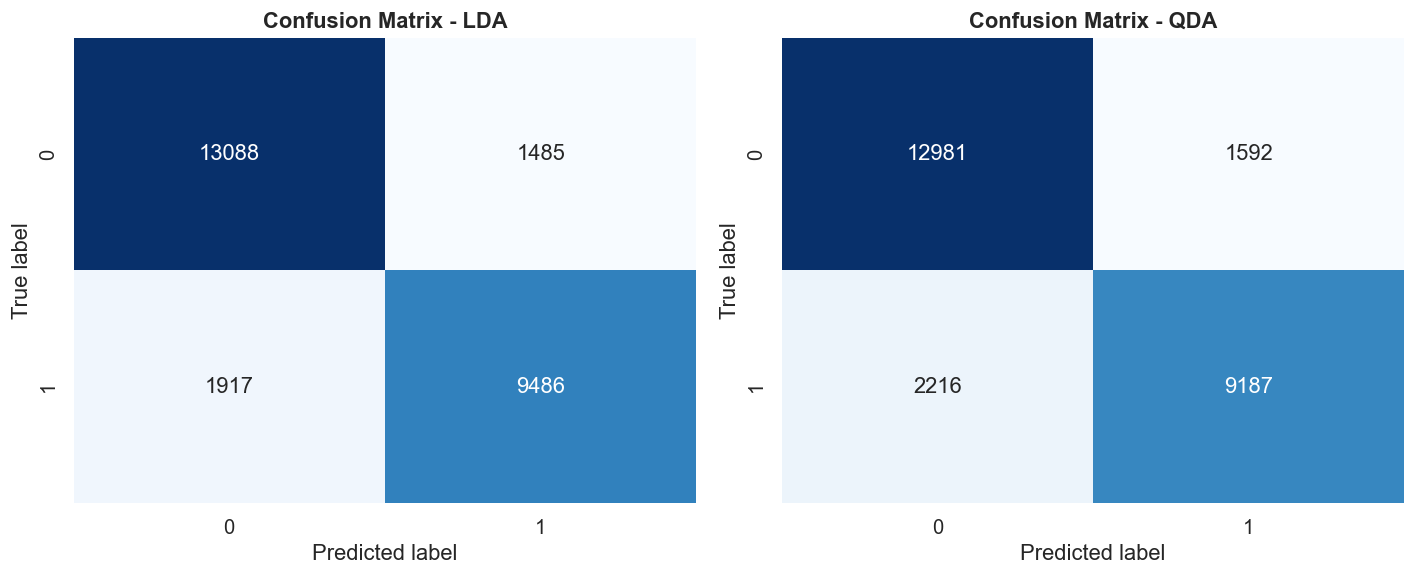

In [10]:
# Vẽ confusion matrix cho LDA và QDA để so sánh lỗi phân loại giữa hai mô hình
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(
    axes,
    [('LDA', y_pred_lda), ('QDA', y_pred_qda)]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax
    )
    ax.set_title(f'Confusion Matrix - {name}', fontweight='bold')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

plt.tight_layout()
plt.show()


**Nhận xét**: Dựa vào biểu đồ, mô hình LDA có tỉ lệ nhận diện đúng lớp 1 cao hơn đáng kể (tương ứng với ô True Positive ở góc dưới cùng bên phải). QDA mắc lỗi False Negatives hơn, tức là có xu hướng đánh giá nhiều hành khách thực sự hài lòng thành "Không hài lòng".

### 3.3 Đường cong ROC 

Đường cong ROC đo lường sức mạnh xếp hạng phân lớp của mô hình theo các ngưỡng xác suất khác nhau.

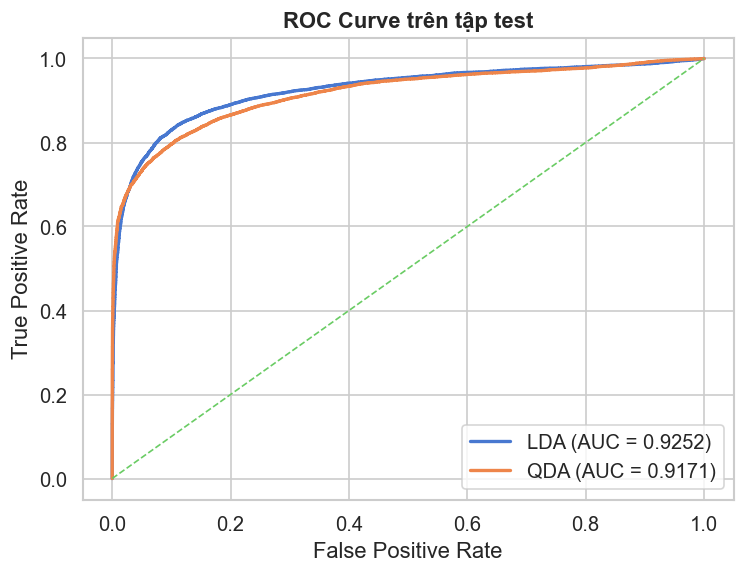

In [11]:
# Vẽ ROC curve + tính AUC để so sánh khả năng phân biệt của LDA và QDA trên tập test
plt.figure(figsize=(7, 5))
for name, y_prob in [('LDA', y_prob_lda), ('QDA', y_prob_qda)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], '--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve trên tập test', fontweight='bold')
plt.legend()
plt.show()


**Nhận xét**: Cả hai mô hình đều uốn cong về phía góc trên bên trái, thể hiện hiệu năng phân định xuất sắc (AUC > 0.91). Tuy nhiên, đường cong của LDA bao trọn phía trên đường của QDA.

### 3.4 Đánh giá tính ổn định bằng Stratified K-Fold CV (k = 5)
Nhằm khẳng định các kết quả tốt ở trên không phải do "may mắn" lấy mẫu trúng tập Test dễ đoán, ta áp dụng kiểm định chéo K-Fold (với k=5) trên tập Huấn luyện. Phương pháp Stratified được dùng để đảm bảo tỷ lệ các lớp 0 và 1 luôn được duy trì đồng đều trong mỗi fold. Kết quả được báo cáo định dạng mean ± std.

In [12]:
def cross_validate_model(model_class, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    metrics = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': [], 'ROC_AUC': []}

    X_np = X.values if isinstance(X, pd.DataFrame) else X
    y_np = y.values if isinstance(y, pd.Series) else y

    for tr_idx, va_idx in skf.split(X_np, y_np):
        model = model_class().fit(X_np[tr_idx], y_np[tr_idx])
        y_pred = model.predict(X_np[va_idx])
        y_prob = model.predict_proba(X_np[va_idx])[:, 1]

        metrics['Accuracy'].append(accuracy_score(y_np[va_idx], y_pred))
        metrics['Precision'].append(precision_score(y_np[va_idx], y_pred))
        metrics['Recall'].append(recall_score(y_np[va_idx], y_pred))
        metrics['F1'].append(f1_score(y_np[va_idx], y_pred))
        metrics['ROC_AUC'].append(roc_auc_score(y_np[va_idx], y_prob))

    # Báo cáo theo định dạng mean ± std
    res = {}
    for k, v in metrics.items():
        res[k] = f"{np.mean(v):.4f} ± {np.std(v):.4f}"
    return res

cv_results = pd.DataFrame([
    cross_validate_model(MyLDA, X_train, y_train),
    cross_validate_model(MyQDA, X_train, y_train)
], index=['MyLDA', 'MyQDA'])

print("Báo cáo 5-fold cross-validation(mean ± std)")
display(cv_results)


Báo cáo 5-fold cross-validation(mean ± std)


,Accuracy,Precision,Recall,F1,ROC_AUC
MyLDA,0.8719 ± 0.0019,0.8645 ± 0.0029,0.8352 ± 0.0043,0.8496 ± 0.0024,0.9262 ± 0.0015
MyQDA,0.8564 ± 0.0019,0.8552 ± 0.0026,0.8048 ± 0.0036,0.8292 ± 0.0024,0.9197 ± 0.0015


**Nhận xét**: Kết quả K-Fold CV hoàn toàn đồng nhất với hiệu năng trên tập Test. Độ lệch chuẩn (std) của các chỉ số là vô cùng nhỏ (dao động chỉ khoảng ±0.002). Điều này chứng minh thuật toán có tính tổng quát hóa tuyệt vời, không bị Overfitting và không bị ảnh hưởng mạnh bởi sự xáo trộn của dữ liệu huấn luyện. Mô hình LDA tiếp tục thể hiện giá trị trung bình (mean) vượt trội hơn QDA.

### 3.5 Vẽ Precision-Recall Curve và So sánh Average Precision (AP)
Biểu đồ Precision-Recall (PR) Curve kết hợp cùng chỉ số Average Precision (AP) sẽ giúp ta đánh giá chính xác hơn về khả năng vừa xác định được được khách hàng hài lòng (Recall cao) vừa đảm bảo sự phán đoán đó không bị sai lệch (Precision cao).

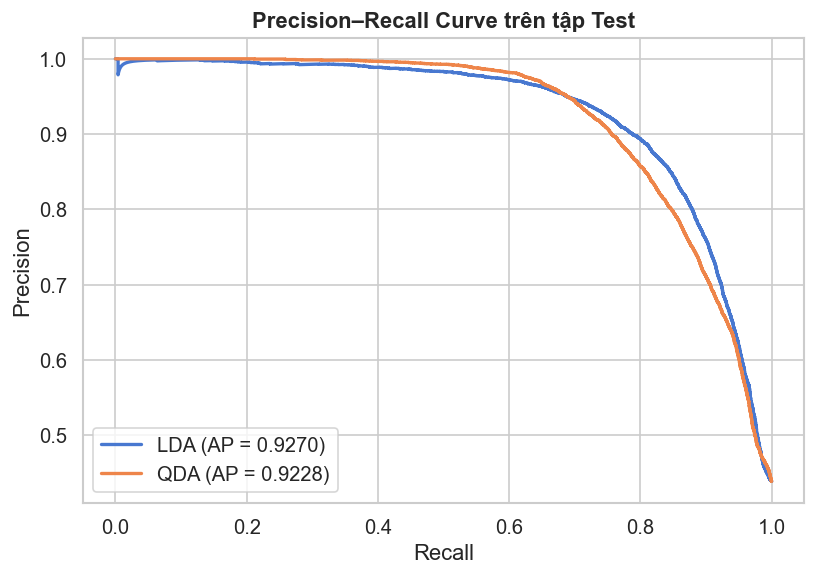

In [13]:
plt.figure(figsize=(7, 5))

for name, y_prob in [('LDA', y_prob_lda), ('QDA', y_prob_qda)]:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, linewidth=2, label=f'{name} (AP = {ap:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve trên tập Test', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

**Nhận xét:** Nhìn vào đồ thị PR Curve, khi ta kéo mức Recall lên cao (tức là khi mô hình cố gắng bắt bằng được mọi hành khách hài lòng), Precision của QDA bị suy giảm mạnh mẽ hơn so với LDA. Chỉ số Average Precision (đo lường diện tích dưới đường PR) của LDA đạt 0.9270, cao hơn QDA (0.9228). Qua đó, hệ thống chấm điểm rủi ro của LDA đáng tin cậy hơn hẳn QDA.

### 3.6 Kiểm định ý nghĩa thống kê (McNemar's Test)

Ta nhận thấy LDA luôn cao điểm hơn QDA, nhưng liệu sự chênh lệch (khoảng 1.5% Accuracy) này là bản chất toán học hay chỉ là yếu tố ngẫu nhiên? Kiểm định McNemar trên cùng một tập Test sẽ tập trung đo lường những mẫu dữ liệu mà mô hình A đoán đúng còn mô hình B đoán sai để đưa ra kết luận thống kê.

In [14]:
def mcnemar_test(y_true, pred_a, pred_b):
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)

    b = np.sum(correct_a & ~correct_b)  # LDA đúng, QDA sai
    c = np.sum(~correct_a & correct_b)  # LDA sai, QDA đúng

    # Xấp xỉ Chi-square
    stat = (abs(b - c) - 1) ** 2 / (b + c) if (b + c) > 0 else 0.0
    # Tính P-value chính xác
    p_value = binomtest(min(b, c), n=b + c, p=0.5, alternative='two-sided').pvalue if (b + c) > 0 else 1.0

    return {
        'LDA_correct_QDA_wrong (b)': int(b),
        'LDA_wrong_QDA_correct (c)': int(c),
        'Chi_square': stat,
        'P-value': p_value
    }

mcnemar_result = pd.DataFrame([mcnemar_test(y_test, y_pred_lda, y_pred_qda)])
print("Kết quả McNemar's test giữa LDA và QDA trên tập test:")
display(mcnemar_result.round(6))

Kết quả McNemar's test giữa LDA và QDA trên tập test:


,LDA_correct_QDA_wrong (b),LDA_wrong_QDA_correct (c),Chi_square,P-value
0,1179,773,84.029201,0.0


**Nhận xét**: Bảng kết quả cho thấy có 1179 mẫu hành khách mà LDA đoán đúng nhưng QDA đoán sai, trong khi QDA chỉ gỡ lại được 773 mẫu. Giá trị P-value = 0.0 (< 0.05). Theo nguyên lý thống kê, ta hoàn toàn có đủ bằng chứng để bác bỏ giả thuyết không (Null Hypothesis). Ta tự tin kết luận rằng sự chênh lệch hiệu năng giữa LDA và QDA không phải do ngẫu nhiên, mà là có ý nghĩa thống kê. Mô hình LDA hoàn toàn ưu việt hơn trong bài toán này.

### 3.7 Phân tích Calibration bằng Reliability Diagram (Biểu đồ độ tin cậy)

Xác suất đầu ra (Predicted Probability) không phải lúc nào cũng phản ánh đúng thực tế. Ví dụ, nếu mô hình báo "80% khách hàng này hài lòng", thì trong thực tế liệu có đúng 80% số khách hàng có cùng mức điểm đó cảm thấy hài lòng không? Biểu đồ độ tin cậy sẽ đối chiếu mức xác suất mô hình in ra với tỷ lệ thực tế.

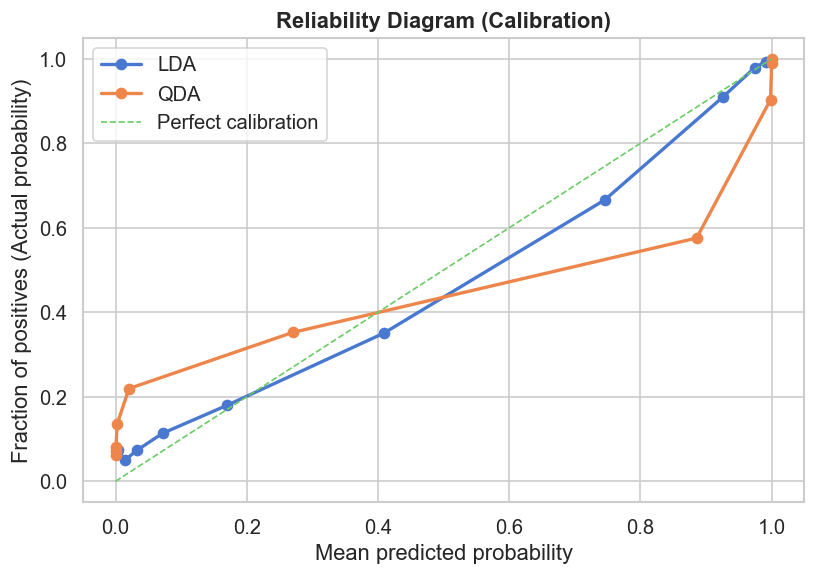

Log-loss LDA: 0.3497
Log-loss QDA: 0.6506


In [15]:
plt.figure(figsize=(7, 5))

for name, y_prob in [('LDA', y_prob_lda), ('QDA', y_prob_qda)]:
    # Chia dữ liệu thành 10 bins phân vị
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', linewidth=2, label=name)

# Đường chéo lý tưởng (Perfect calibration)
plt.plot([0, 1], [0, 1], '--', linewidth=1, label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives (Actual probability)')
plt.title('Reliability Diagram (Calibration)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Tính Log-loss để củng cố phân tích
print(f"Log-loss LDA: {log_loss(y_test, lda_full.predict_proba(X_test)):.4f}")
print(f"Log-loss QDA: {log_loss(y_test, qda_full.predict_proba(X_test)):.4f}")

**Nhận xét:** 
- LDA cực kỳ đáng tin cậy: Đường cong của LDA bám rất sát đường chéo lý tưởng (Perfect Calibration). Xác suất mà LDA dự đoán hoàn toàn đồng nhất với xác suất thực tế.
- QDA thì quá tự tin (overconfident): Đường cong của QDA bị gãy khúc, tạo thành dạng chữ "S ngược", có xu hướng đẩy các giá trị xác suất về sát hai cực 0.0 và 1.0 một cách thái quá. Nguyên nhân là do QDA nhân các ma trận nghịch đảo $\Sigma_k^{-1}$ riêng biệt, khiến biên quyết định bị uốn cong lố. Sự "tự tin thái quá" này khiến QDA bị phạt rất nặng ở hàm mất mát Log-loss (0.6506), cao gần gấp đôi so với Log-loss ổn định của LDA (0.3497).

## 4. So sánh LDA và QDA

### 4.1 Phân tích độ phức tạp của không gian tham số (Parameter Complexity)
Sự khác biệt cốt lõi về mặt toán học giữa LDA và QDA nằm ở giả định về ma trận hiệp phương sai. Với không gian dữ liệu $d = 24$ chiều và $K = 2$ lớp, số lượng tham số mà mỗi mô hình cần học từ tập huấn luyện được tính toán như sau:

- **LDA** (Giả thiết hiệp phương sai chung): 
  - **Vector trung bình**: $ K \times d = 48 $ tham số
  - **Ma trận hiệp phương sai dùng chung** $ \Sigma $:  
  $ \dfrac{d(d+1)}{2} = \dfrac{24 \times 25}{2} = 300 $ tham số
  - **Xác suất tiên nghiệm (Prior)**: $ K - 1 = 1 $ tham số

  - **Tổng cộng: $ 48 + 300 + 1 = 349 $ tham số**

- **QDA** (Giả thiết hiệp phương sai riêng biệt):
  - **Vector trung bình**: $ 48 $ tham số
  - **Ma trận hiệp phương sai riêng cho từng lớp** $ \Sigma_k $:  
  $ K \times \dfrac{d(d+1)}{2} = 2 \times 300 = 600 $ tham số
  - **Xác suất tiên nghiệm (Prior)**: $ 1 $ tham số

  - **Tổng cộng: $ 48 + 600 + 1 = 649 $ tham số**

In [ ]:
# So sánh độ phức tạp tham số và độ giống nhau giữa các covariance matrix

classes = np.unique(y_train)
d = X_train.shape[1]
K = len(classes)

# số phần tử độc lập trong ma trận hiệp phương sai đối xứng
n_cov_params = d * (d + 1) // 2

complexity_df = pd.DataFrame([
    {
        'model': 'LDA',
        'mean_params': K * d,
        'covariance_params': n_cov_params,
        'prior_params': K - 1,
        'total_params': K * d + n_cov_params + (K - 1)
    },
    {
        'model': 'QDA',
        'mean_params': K * d,
        'covariance_params': K * n_cov_params,
        'prior_params': K - 1,
        'total_params': K * d + K * n_cov_params + (K - 1)
    }
])
print('Bảng số tham số cần ước lượng:')
display(complexity_df)

Bảng số tham số cần ước lượng:


,model,mean_params,covariance_params,prior_params,total_params
0,LDA,48,300,1,349
1,QDA,48,600,1,649


**Nhận xét:**  
QDA yêu cầu số lượng tham số cần ước lượng gần **gấp đôi** so với LDA (**649 so với 349 tham số**). Trong không gian nhiều chiều, việc phải ước lượng một lượng lớn tham số độc lập cho các ma trận hiệp phương sai riêng $\Sigma_k$ giúp QDA linh hoạt hơn, nhưng đồng thời cũng khiến mô hình **dễ bị quá khớp (overfitting)** với nhiễu dữ liệu.

Ngược lại, việc LDA buộc cả hai lớp dùng chung một cấu trúc hiệp phương sai $\Sigma$ hoạt động như một dạng **regularization tự nhiên**, giúp mô hình ổn định hơn và thường tổng quát hóa tốt hơn khi dữ liệu không đủ lớn.

### 4.2. Đánh giá mức độ tương đồng của ma trận hiệp phương sai giữa hai lớp

Để kiểm chứng xem giả thiết **“dùng chung ma trận hiệp phương sai”** của LDA có thực sự hợp lý với bộ dữ liệu *Airline Passenger Satisfaction* hay không, nhóm đã trực tiếp đo lường sự khác biệt giữa $\Sigma_0$ (lớp **Neutral/Dissatisfied**) và $\Sigma_1$ (lớp **Satisfied**) trên tập huấn luyện.

In [17]:
cov0 = params[classes[0]]['Sigma']
cov1 = params[classes[1]]['Sigma']
triu_idx = np.triu_indices_from(cov0)
cov_similarity_df = pd.DataFrame([{
    'frobenius_norm_diff': np.linalg.norm(cov0 - cov1, ord='fro'),
    'relative_frobenius_diff': np.linalg.norm(cov0 - cov1, ord='fro') /
        ((np.linalg.norm(cov0, ord='fro') + np.linalg.norm(cov1, ord='fro')) / 2),
    'upper_triangle_correlation': np.corrcoef(cov0[triu_idx], cov1[triu_idx])[0, 1],
    'diagonal_variance_correlation': np.corrcoef(np.diag(cov0), np.diag(cov1))[0, 1]
}])

print('Mức độ giống nhau giữa hai covariance matrix của hai lớp:')
display(cov_similarity_df.round(4))


Mức độ giống nhau giữa hai covariance matrix của hai lớp:


,frobenius_norm_diff,relative_frobenius_diff,upper_triangle_correlation,diagonal_variance_correlation
0,3.4298,0.6235,0.8259,0.6566


**Nhận xét:**

- **Độ tương quan rất cao**: Hệ số tương quan của phần tam giác trên (*upper triangle*) giữa hai ma trận đạt **0.8259**, trong khi tương quan phương sai trên đường chéo chính đạt **0.6566**. Điều này chứng tỏ hình dáng phân bố và cấu trúc tương quan giữa các đặc trưng của khách hàng Hài lòng và Không hài lòng là rất giống nhau.

- **Vì sao LDA phù hợp hơn**: Khi hai lớp đã có cấu trúc hiệp phương sai tương đồng, việc QDA cố gắng học hai ma trận riêng biệt trở nên **thừa mức cần thiết**, và có nguy cơ học theo các dao động nhiễu cục bộ trong dữ liệu. Trong bối cảnh đó, giả thiết của LDA là **hợp lý hơn** và giúp mô hình hoạt động ổn định hơn trên tập kiểm tra.


### 4.3. Phân tích đồ thị tương quan phương sai (Variance Correlation Analysis)

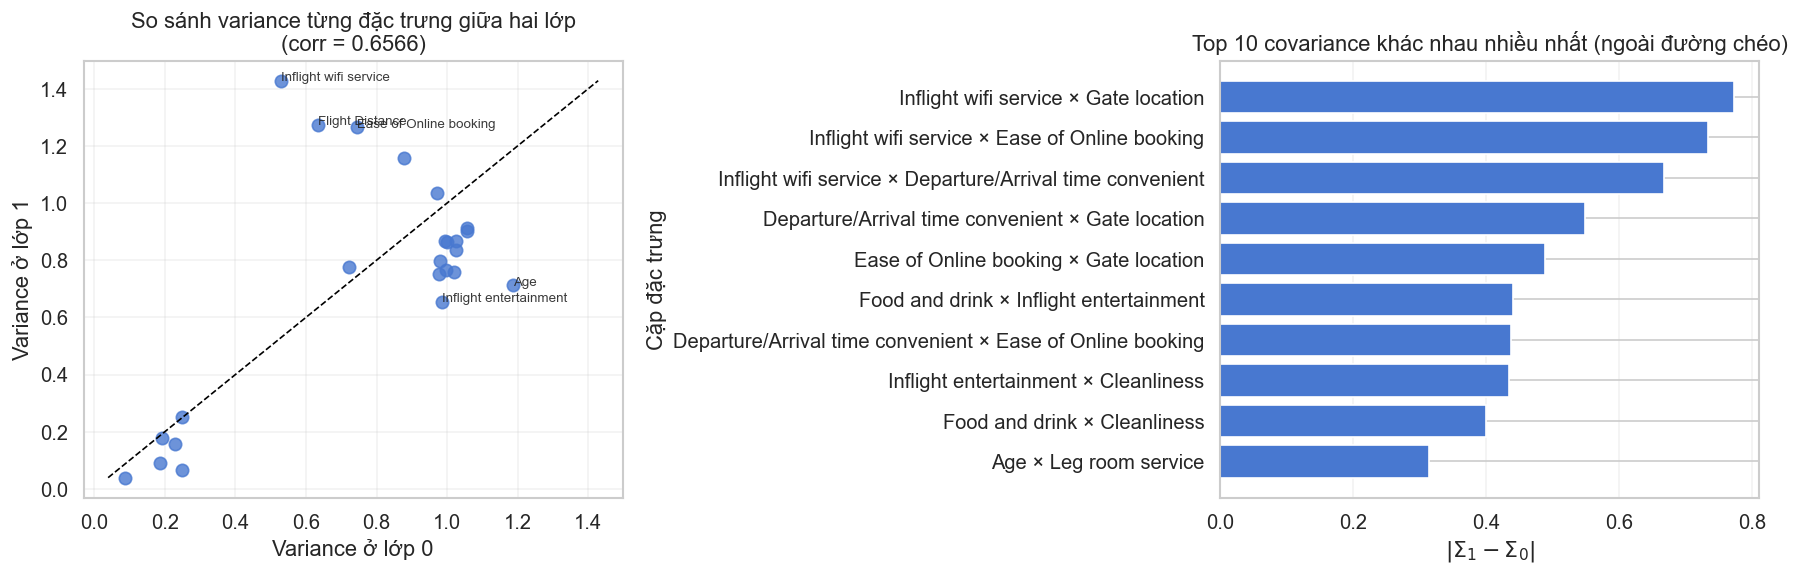

In [18]:

diag_var_diff = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'var_class_0': np.diag(cov0),
    'var_class_1': np.diag(cov1)
})
diag_var_diff['abs_diff'] = np.abs(
    diag_var_diff['var_class_1'] - diag_var_diff['var_class_0']
)

# Phân tích covariance ngoài đường chéo
triu_idx_offdiag = np.triu_indices_from(cov0, k=1)

pairs = []
for i, j in zip(*triu_idx_offdiag):
    pair_name = f'{FEATURE_NAMES[i]} × {FEATURE_NAMES[j]}'
    pairs.append((pair_name, np.abs(cov0[i, j] - cov1[i, j])))

top_cov_diff = (
    pd.DataFrame(pairs, columns=['pair', 'abs_cov_diff'])
    .sort_values('abs_cov_diff', ascending=False)
    .head(10)
    .sort_values('abs_cov_diff', ascending=True)
)

diag_corr = np.corrcoef(
    diag_var_diff['var_class_0'],
    diag_var_diff['var_class_1']
)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x_diag = diag_var_diff['var_class_0'].values
y_diag = diag_var_diff['var_class_1'].values

axes[0].scatter(x_diag, y_diag, s=55, alpha=0.8)

lim_min = min(x_diag.min(), y_diag.min())
lim_max = max(x_diag.max(), y_diag.max())
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], '--', color='black', linewidth=1)

for _, row in diag_var_diff.nlargest(5, 'abs_diff').iterrows():
    axes[0].annotate(
        row['feature'],
        (row['var_class_0'], row['var_class_1']),
        fontsize=8,
        alpha=0.9
    )

axes[0].set_title(f'So sánh variance từng đặc trưng giữa hai lớp\n(corr = {diag_corr:.4f})')
axes[0].set_xlabel('Variance ở lớp 0')
axes[0].set_ylabel('Variance ở lớp 1')
axes[0].grid(alpha=0.25)

# --- Bar chart top covariance khác nhau nhiều nhất ---
axes[1].barh(top_cov_diff['pair'], top_cov_diff['abs_cov_diff'])
axes[1].set_title('Top 10 covariance khác nhau nhiều nhất (ngoài đường chéo)')
axes[1].set_xlabel(r'$|\Sigma_1 - \Sigma_0|$')
axes[1].set_ylabel('Cặp đặc trưng')
axes[1].grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

**Nhận xét đồ thị:**
- **Biểu đồ scatter:** Các điểm dữ liệu phân bố tập trung khá sát quanh đường chéo lý tưởng $y = x $. Điều này cho thấy **phương sai của từng đặc trưng đơn lẻ** ở hai lớp là **xấp xỉ nhau**, tức mức độ phân tán của dữ liệu theo từng biến không khác biệt nhiều giữa hai nhóm.

- **Biểu đồ cột (bar chart):** Dù có mức độ tương đồng tổng thể cao, vẫn tồn tại một số cặp biến có độ chênh covariance đáng chú ý, (chẳng hạn các tương tác liên quan đến  Inflight wifi service hay Class_Business). Tuy nhiên, những khác biệt cục bộ này **không đủ mạnh** để buộc mô hình phải dùng đến **đường biên quyết định bậc hai** như QDA. Nói cách khác, lợi ích từ độ linh hoạt bổ sung của QDA là **không đủ lớn** để bù lại chi phí tăng số tham số và rủi ro overfitting.


### 4.4. Tổng kết: Khi nào nên sử dụng LDA thay vì QDA?

Từ cả nền tảng lý thuyết lẫn kết quả thực nghiệm, ta rút ra một số kết luận như sau

**Nên chọn LDA khi**

- **Ma trận hiệp phương sai giữa các lớp tương đồng nhau:** Như đã chứng minh ở trên, hệ số tương quan giữa hai ma trận hiệp phương sai đạt mức cao (**0.8259**), cho thấy giả thiết của LDA là phù hợp.

- **Cần một mô hình ổn định, ít tham số hơn:** Với chỉ **349 tham số**, LDA ít bị ảnh hưởng bởi nhiễu hơn và phù hợp hơn trong bối cảnh số chiều khá lớn.

- **Muốn xác suất đầu ra đáng tin cậy hơn:** Việc dùng một ma trận hiệp phương sai chung giúp LDA tránh được hiện tượng dự đoán xác suất quá cực đoan, nhờ đó thường cho **log-loss tốt hơn** và calibration ổn định hơn.

**Chỉ nên chọn QDA khi**

- **Phân bố giữa các lớp thực sự khác nhau rõ rệt:** Tức là các ma trận hiệp phương sai $ \Sigma_k $ khác nhau đáng kể, làm cho đường biên bậc hai trở nên cần thiết.

- **Có rất nhiều dữ liệu huấn luyện so với số chiều đặc trưng:** Vì QDA phải ước lượng số lượng tham số cỡ $ O(Kd^2) $, nên nếu dữ liệu không đủ lớn, mô hình rất dễ học sai cấu trúc phương sai thật.

**Kết luận chung:** Trong bộ dữ liệu này, cả phân tích lý thuyết lẫn thực nghiệm đều cho thấy **LDA là lựa chọn phù hợp hơn QDA**. Lý do chính là:

1. Số tham số của LDA nhỏ hơn đáng kể
2. Cấu trúc hiệp phương sai giữa hai lớp có mức tương đồng cao
3. QDA không thu được lợi ích rõ rệt từ độ linh hoạt bổ sung
4. Trong khi LDA cho mô hình ổn định, dễ tổng quát hóa và đáng tin cậy hơn về mặt xác suất đầu ra.

## 5. Lưu kết quả

In [19]:
os.makedirs(PROC_DATA_PATH, exist_ok=True)

save_models = {
    "LDA": {
        "model": lda_full,
        "model_name": "MyLDA",
        "metrics": lda_metrics,
        "y_pred": y_pred_lda,
        "y_prob": y_prob_lda
    },
    "QDA": {
        "model": qda_full,
        "model_name": "MyQDA",
        "metrics": qda_metrics,
        "y_pred": y_pred_qda,
        "y_prob": y_prob_qda
    }
}

MODEL_PATH = os.path.join(PROC_DATA_PATH, "lda_qda_models.pkl")

with open(MODEL_PATH, "wb") as f:
    pickle.dump(save_models, f)

print(f"Đã lưu model tại: {MODEL_PATH}")

Đã lưu model tại: d:\2025-2026 HKII\Machine Learning\Project1\Machine-Learning---Project-1-\data\processed\lda_qda_models.pkl
